# Week 7: 딥러닝 기초 (2026-05-11)

## 1. 실습 개요
- 인공 신경망의 기본 원리 이해
- PyTorch 기초 및 MLP 구현

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import  train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import  StandardScaler, MinMaxScaler

import torch
from torch import nn
from torch.utils.data import  DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor

from config import CONTENT_DIR

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['font.family'] = 'NanumGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False

In [3]:
def make_DataSet(X_train, X_val, y_train, y_val, batch_size = 32) :
    # batch_size : 모델이 한 번에 몇 개의 데이터를 보고 학습할지 정하는 값

    # 데이터 텐서로 변환
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = False)

    return train_loader, X_val_tensor, y_val_tensor

def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    tr_loss = 0
    model.train()                                           # 훈련 모드로 설정
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)


        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss


        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    tr_loss /= num_batches

    return tr_loss.item()

def evaluate(X_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()

    with torch.no_grad():
        X, y = X_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(X)
        eval_loss = loss_fn(pred, y).item()

    return eval_loss, pred

device = "cuda" if torch.cuda.is_available() else "cpu"
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 사용 시
    torch.backends.cudnn.deterministic = True # 연산 결과 고정
    torch.backends.cudnn.benchmark = False # 최적화 알고리즘 고정
# 행운의 숫자 하나를 골라 시드를 고정합니다.
set_seed(42)

def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


Epoch 50, train loss : 18.969540, val loss : 24.455437
Epoch 100, train loss : 12.476608, val loss : 18.327759
Epoch 150, train loss : 9.310754, val loss : 15.287742
Epoch 200, train loss : 7.989882, val loss : 14.834798


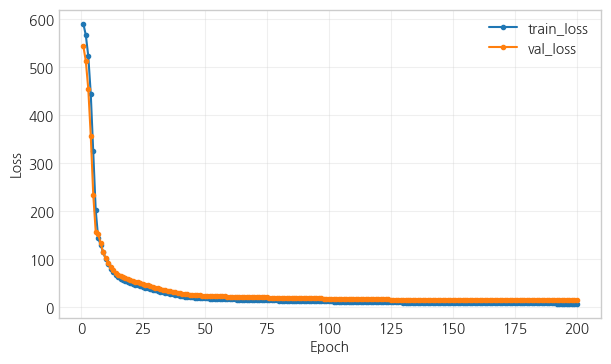

MSE : 14.834798
MAE : 2.734923
MAPE : 0.156504


In [4]:
path = f"{CONTENT_DIR}/boston.csv"
df = pd.read_csv(path)
df.head()

target = 'medv'
X = df.drop(target, axis=1)
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=2026
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


train_loader, X_val_ts, y_val_ts = make_DataSet(
    X_train, X_val, y_train, y_val, batch_size=32
)

n_feature = X.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 128),
    nn.ReLU(),
    
    nn.Linear(128, 64),
    nn.ReLU(),
    
    nn.Linear(64, 1)
).to(device)

loss_fn = nn.MSELoss()
optimizer = Adam(
    model1.parameters(), lr=0.001
)  

epochs = 200
tr_loss_list, val_loss_list = [], []

for t in range(1, epochs + 1):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)
    
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    if t % 50 == 0:
        print(f"Epoch {t}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

loss, pred = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)

mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())

print(f'MSE : {loss:4f}')
print(f'MAE : {mae:4f}')
print(f'MAPE : {mape:4f}')

Epoch 50, train loss : 1.139663, val loss : 2.101356
Epoch 100, train loss : 0.541102, val loss : 1.619791
Epoch 150, train loss : 0.374514, val loss : 1.689177


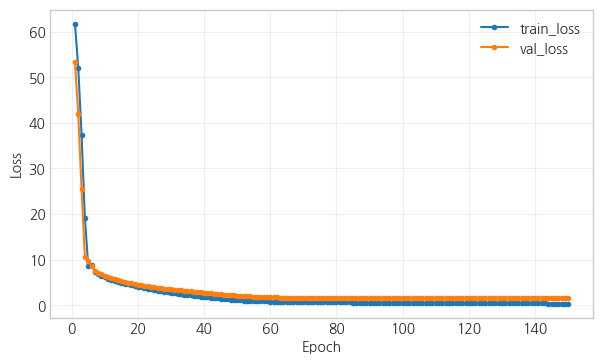

MSE : 1.689177
MAE : 1.004688
MAPE : 0.270906


In [5]:
path = CONTENT_DIR / "Carseats.csv"
df = pd.read_csv(path)
df.head()

target = 'Sales'
cat_cols = ['ShelveLoc', 'Education', 'Urban', 'US']
X = df.drop(target, axis = 1)
X = pd.get_dummies(X, columns = cat_cols, drop_first = True)
y = df.loc[:, target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=2026
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)



train_loader, X_val_ts, y_val_ts = make_DataSet(
    X_train, X_val, y_train, y_val, batch_size=32
)

n_feature = X.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 128),
    nn.ReLU(),
    
    nn.Linear(128, 64),
    nn.ReLU(),
    
    nn.Linear(64, 1)
).to(device)

loss_fn = nn.MSELoss()
optimizer = Adam(
    model1.parameters(), lr=0.001
)  

epochs = 150
tr_loss_list, val_loss_list = [], []

for t in range(1, epochs + 1):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)
    
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    if t % 50 == 0:
        print(f"Epoch {t}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

loss, pred = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)

mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())

print(f'MSE : {loss:4f}')
print(f'MAE : {mae:4f}')
print(f'MAPE : {mape:4f}')

Epoch 20, train loss : 0.412687, val loss : 0.423619
Epoch 40, train loss : 0.406326, val loss : 0.415073
Epoch 60, train loss : 0.402077, val loss : 0.407191
Epoch 80, train loss : 0.396841, val loss : 0.402051
Epoch 100, train loss : 0.390817, val loss : 0.397560


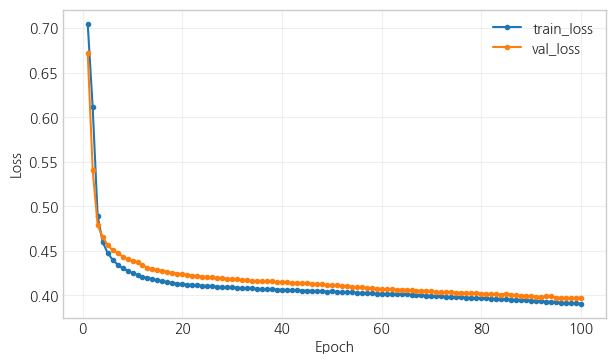

Accuracy: 0.8268

[Classification Report]
              precision    recall  f1-score   support

        Dead       0.81      0.93      0.87       108
    Survived       0.86      0.68      0.76        71

    accuracy                           0.83       179
   macro avg       0.84      0.80      0.81       179
weighted avg       0.83      0.83      0.82       179


[Confusion Matrix]
[[100   8]
 [ 23  48]]


In [6]:
path = CONTENT_DIR / 'titanic.csv'
df = pd.read_csv(path)
df.drop(['Age_scale1', 'AgeGroup', 'SibSp', 'Parch'], axis=1, inplace=True)

target = 'Survived'
X = pd.get_dummies(df.drop(target, axis=1), columns=['Sex', 'Embarked'], drop_first=True)
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                  test_size=.2,
                                                  random_state=2026)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

train_loader, X_val_ts, y_val_ts = make_DataSet(
    X_train, X_val, y_train, y_val, batch_size=16
)

n_feature = X.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 64),
    nn.ReLU(),
    
    nn.Linear(64, 32),
    nn.ReLU(),
    
    nn.Linear(32, 16),
    nn.ReLU(),
    
    nn.Linear(16, 1),
    nn.Sigmoid()
).to(device)

loss_fn = nn.BCELoss()
optimizer = Adam(
    model1.parameters(), lr=0.001
)  

epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(1, epochs + 1):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)
    
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    if t % 20 == 0:
        print(f"Epoch {t}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

loss, pred = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)

y_pred_label = (pred >= 0.5).float()
# 텐서를 넘파이로 변환
y_true = y_val_ts.cpu().numpy()
y_pred = y_pred_label.cpu().numpy()
# 1. 정확도 출력
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# 2. 종합 리포트 (Precision, Recall, F1-score 포함)
print("\n[Classification Report]")
print(classification_report(y_true, y_pred, target_names=['Dead', 'Survived']))
# 3. 혼동 행렬 (어디서 틀렸는지 상세 확인)
print("\n[Confusion Matrix]")
print(confusion_matrix(y_true, y_pred))

Epoch 10, train loss : 0.858789, val loss : 0.781988
Epoch 20, train loss : 0.800610, val loss : 0.724746
Epoch 30, train loss : 0.770251, val loss : 0.705565
Epoch 40, train loss : 0.748097, val loss : 0.697049
Epoch 50, train loss : 0.730411, val loss : 0.689324
Epoch 60, train loss : 0.716295, val loss : 0.683543
Epoch 70, train loss : 0.703287, val loss : 0.677804
Epoch 80, train loss : 0.691098, val loss : 0.673727
Epoch 90, train loss : 0.679789, val loss : 0.669150
Epoch 100, train loss : 0.668781, val loss : 0.663403


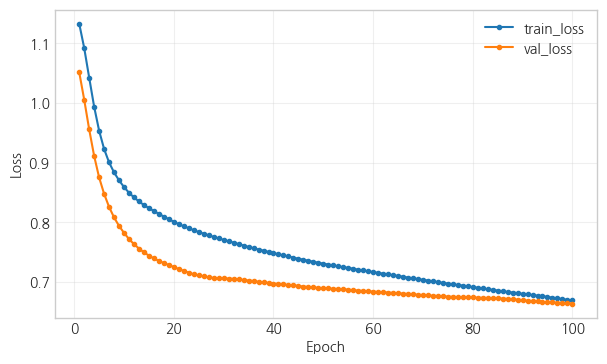

Accuracy: 0.8400

[Classification Report]
              precision    recall  f1-score   support

         0.0       0.95      0.86      0.90       214
         1.0       0.47      0.75      0.57        36

    accuracy                           0.84       250
   macro avg       0.71      0.80      0.74       250
weighted avg       0.88      0.84      0.85       250


[Confusion Matrix]
[[183  31]
 [  9  27]]


In [7]:
df = pd.read_csv(CONTENT_DIR / "Attrition_train_validation.csv")
df['Attrition'] = np.where(df['Attrition']=='Yes', 1, 0)

target = 'Attrition'
X = pd.get_dummies(df.drop(target, axis = 1), drop_first=True)
y = df.loc[:, target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.2, random_state = 20)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

train_loader, X_val_ts, y_val_ts = make_DataSet(
    X_train, X_val, y_train, y_val, batch_size=8
)

n_feature = X.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Linear(n_feature, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
).to(device)

optimizer = Adam(model1.parameters(), lr=0.001)

# 0번(No) 개수 / 1번(Yes) 개수
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
pos_weight_value = neg_count / pos_count # 약 5.xxx

# 텐서 형태로 변환 (장치 설정 포함)
pos_weight = torch.tensor([pos_weight_value]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(1, epochs + 1):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)
    
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    if t % 10 == 0:
        print(f"Epoch {t}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

# 예측 시 수동으로 시그모이드 적용
loss, logits = evaluate(X_val_ts, y_val_ts, model1, loss_fn, device)
pred = torch.sigmoid(logits) # 확률값으로 변환

y_pred_label = (pred >= 0.5).float()

# 텐서를 넘파이로 변환
y_true = y_val_ts.cpu().numpy()
y_pred = y_pred_label.cpu().numpy()
# 1. 정확도 출력
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# 2. 종합 리포트 (Precision, Recall, F1-score 포함)
print("\n[Classification Report]")
print(classification_report(y_true, y_pred))
# 3. 혼동 행렬 (어디서 틀렸는지 상세 확인)
print("\n[Confusion Matrix]")
print(confusion_matrix(y_true, y_pred))

In [8]:
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

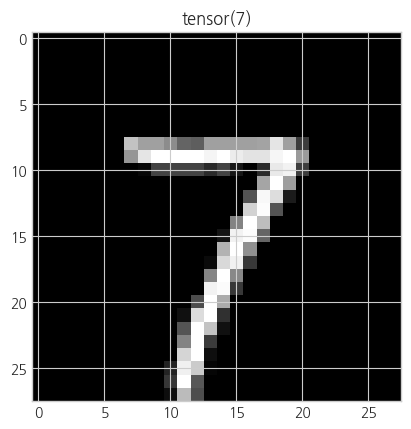

In [9]:
n = 2348
image, label = train_dataset.data[n], train_dataset.targets[n]

plt.imshow(image, cmap='gray')
plt.title(label)
plt.show()

In [24]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

X_val, X_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

# 모든 픽셀값 [0,1] 범위로 변환
X_val = X_val / 255
X_test = X_test / 255

X_val = X_val.view(5000, 1, 28, 28)     # [1 * 28 * 28 이미지 5000장] 구조로 변환
X_test = X_test.view(5000, 1, 28, 28)

n_feature = 28 * 28
n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 50),
    nn.ReLU(),
    nn.Linear(50,10)        # 총 class 10개
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.01)

epochs = 5
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.244056, val loss : 0.207984
Epoch 2, train loss : 0.140264, val loss : 0.212064
Epoch 3, train loss : 0.123612, val loss : 0.206258
Epoch 4, train loss : 0.114297, val loss : 0.240629
Epoch 5, train loss : 0.100590, val loss : 0.236407


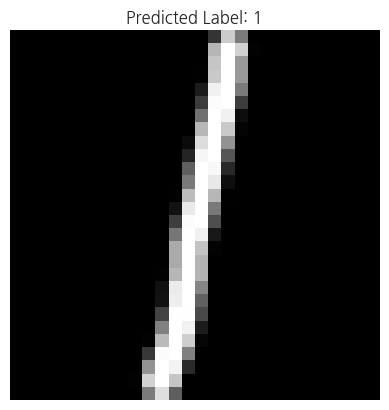

Model device: cpu
Image Tensor device: cpu


In [ ]:
import torchvision.transforms as transforms
from PIL import Image
import cv2

model1.eval()

image_path = f"{CONTENT_DIR}/11.png"

# 흰색 배경 → 검은색 배경으로 반전하기 위해 흑백 이미지로 변환
image = Image.open(image_path).convert("L")
image = np.array(image)
image = cv2.bitwise_not(image)        # 색 반전
# ... (전체 이미지에서 boundingRect 구하는 부분까지는 동일)
x, y, w, h = cv2.boundingRect(image)
roi = image[y:y+h, x:x+w]
# 비율 유지하며 정사각형 만들기 (Padding 추가)
max_side = max(w, h)
# 빈 검은색 캔버스 생성
padded_roi = np.zeros((max_side, max_side), dtype=np.uint8)
# 숫자를 중앙에 배치할 위치 계산
offset_x = (max_side - w) // 2
offset_y = (max_side - h) // 2
padded_roi[offset_y:offset_y+h, offset_x:offset_x+w] = roi
# 이제 이 padded_roi를 28x28로 리사이즈
roi = cv2.resize(padded_roi, (28, 28), interpolation=cv2.INTER_AREA)

Image.fromarray(image).save(CONTENT_DIR / "processed_image.png")

transform = transforms.Compose([
    transforms.ToTensor()  # 학습 데이터와 동일하게 [0, 1] 범위로 변환
])

image_tensor = transform(Image.fromarray(roi)).unsqueeze(0).to(device)
with torch.no_grad():
    output = model1(image_tensor)
    predicted_label = torch.argmax(output, dim=1).item()

plt.imshow(roi, cmap="gray")
plt.title(f"Predicted Label: {predicted_label}")
plt.axis("off")
plt.show()

print(f"Model device: {next(model1.parameters()).device}")
print(f"Image Tensor device: {image_tensor.device}")